# Logistic Regression 

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, precision_score,recall_score,f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


## Load Features

In [2]:
hog_X_train = np.load("../data/features/hog_X_train.npy")
hog_y_train = np.load("../data/features/hog_y_train.npy")

hog_X_val = np.load("../data/features/hog_X_val.npy")
hog_y_val = np.load("../data/features/hog_y_val.npy")

hog_X_test = np.load("../data/features/hog_X_test.npy")
hog_y_test = np.load("../data/features/hog_y_test.npy")

pca_X_train = np.load("../data/features/pca_X_train.npy")
pca_y_train = np.load("../data/features/pca_y_train.npy")

pca_X_val = np.load("../data/features/pca_X_val.npy")
pca_y_val = np.load("../data/features/pca_y_val.npy")

pca_X_test = np.load("../data/features/pca_X_test.npy")
pca_y_test = np.load("../data/features/pca_y_test.npy")

resnet_X_train = np.load("../data/features/resnet_X_train.npy")
resnet_y_train = np.load("../data/features/resnet_y_train.npy")

resnet_X_val = np.load("../data/features/resnet_X_val.npy")
resnet_y_val = np.load("../data/features/resnet_y_val.npy")

resnet_X_test = np.load("../data/features/resnet_X_test.npy")
resnet_y_test = np.load("../data/features/resnet_y_test.npy")

# Logistic Regression (HOG)
* HOG is large dimensional --> LR usually performs poorly

🔹 TRAINING METRICS
Accuracy: 0.9474698176213717
Precision: 0.9291180024164317
Recall: 0.908267716535433
F1-Score: 0.9185745570376269
------------------------------------------------------------
🔹 TESTING METRICS
Accuracy: 0.6604850213980028
Precision: 0.5158339197748065
Recall: 0.42840444184687315
F1-Score: 0.46807151979565775
------------------------------------------------------------

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      3196
           1       0.52      0.43      0.47      1711

    accuracy                           0.66      4907
   macro avg       0.62      0.61      0.61      4907
weighted avg       0.65      0.66      0.65      4907



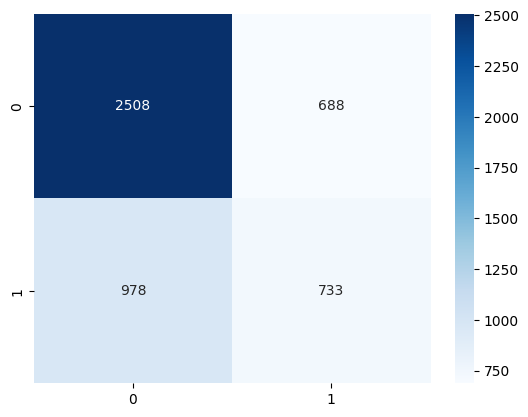

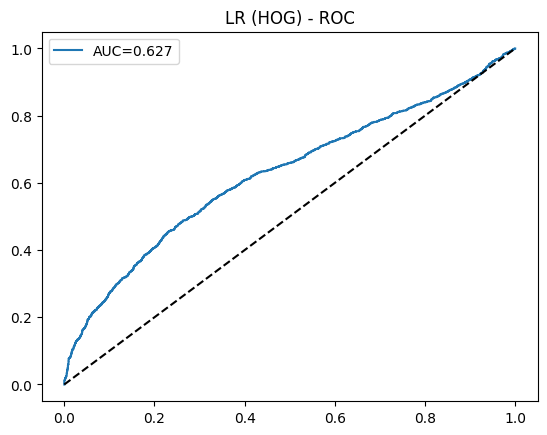

In [3]:
scaler = StandardScaler()
hog_X_train_s = scaler.fit_transform(hog_X_train)
hog_X_test_s = scaler.transform(hog_X_test)

lr = LogisticRegression(max_iter=3000)
lr.fit(hog_X_train_s, hog_y_train)

y_pred_train = lr.predict(hog_X_train_s)

train_accuracy = accuracy_score(hog_y_train, y_pred_train)
train_precision = precision_score(hog_y_train, y_pred_train)
train_recall = recall_score(hog_y_train, y_pred_train)
train_f1 = f1_score(hog_y_train, y_pred_train)

print("🔹 TRAINING METRICS")
print("Accuracy:", train_accuracy)
print("Precision:", train_precision)
print("Recall:", train_recall)
print("F1-Score:", train_f1)
print("-" * 60)

y_pred_test = lr.predict(hog_X_test_s)

test_accuracy = accuracy_score(hog_y_test, y_pred_test)
test_precision = precision_score(hog_y_test, y_pred_test)
test_recall = recall_score(hog_y_test, y_pred_test)
test_f1 = f1_score(hog_y_test, y_pred_test)

print("🔹 TESTING METRICS")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1-Score:", test_f1)
print("-" * 60)


print("\n🔹 Classification Report:")
print(classification_report(hog_y_test, y_pred_test))

cm = confusion_matrix(hog_y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()

y_prob = lr.predict_proba(hog_X_test_s)[:, 1]
fpr, tpr, _ = roc_curve(hog_y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("LR (HOG) - ROC")
plt.legend()
plt.show()

# Logistic Regression (PCA)
* LR usually performs better on PCA as features are lower dimensional and independent

🔹 TRAINING METRICS
Accuracy: 0.9532922339241373
Precision: 0.9335901182095896
Recall: 0.9224409448818898
F1-Score: 0.9279820450194732
------------------------------------------------------------
🔹 TESTING METRICS
Accuracy: 0.8037497452618708
Precision: 0.6991480298189563
Recall: 0.7673874926943308
F1-Score: 0.7316801337419894
------------------------------------------------------------

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      3196
           1       0.70      0.77      0.73      1711

    accuracy                           0.80      4907
   macro avg       0.78      0.80      0.79      4907
weighted avg       0.81      0.80      0.81      4907



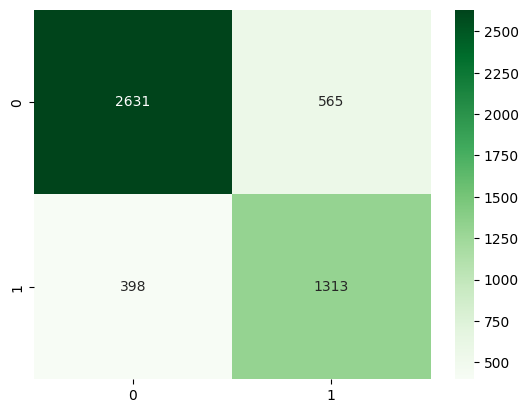

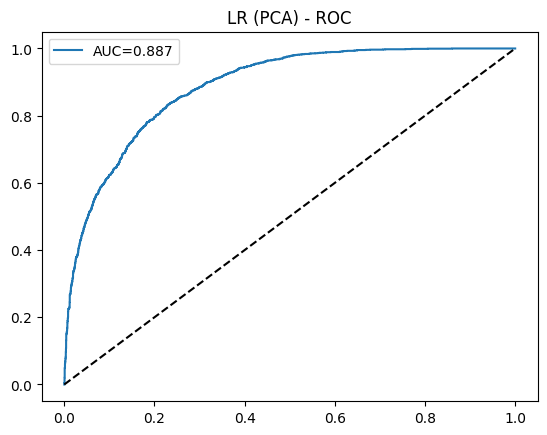

In [6]:
scaler = StandardScaler()
pca_X_train_s = scaler.fit_transform(pca_X_train)
pca_X_test_s = scaler.transform(pca_X_test)

lr_pca = LogisticRegression(max_iter=3000)
lr_pca.fit(pca_X_train_s, pca_y_train)

y_pred_train = lr_pca.predict(pca_X_train_s)

train_accuracy = accuracy_score(pca_y_train, y_pred_train)
train_precision = precision_score(pca_y_train, y_pred_train)
train_recall = recall_score(pca_y_train, y_pred_train)
train_f1 = f1_score(pca_y_train, y_pred_train)

print("🔹 TRAINING METRICS")
print("Accuracy:", train_accuracy)
print("Precision:", train_precision)
print("Recall:", train_recall)
print("F1-Score:", train_f1)
print("-" * 60)

y_pred_test = lr_pca.predict(pca_X_test_s)

test_accuracy = accuracy_score(pca_y_test, y_pred_test)
test_precision = precision_score(pca_y_test, y_pred_test)
test_recall = recall_score(pca_y_test, y_pred_test)
test_f1 = f1_score(pca_y_test, y_pred_test)

print("🔹 TESTING METRICS")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1-Score:", test_f1)
print("-" * 60)

print("\n🔹 Classification Report:")
print(classification_report(pca_y_test, y_pred_test))

cm = confusion_matrix(pca_y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.show()

y_prob = lr_pca.predict_proba(pca_X_test_s)[:, 1]
fpr, tpr, _ = roc_curve(pca_y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("LR (PCA) - ROC")
plt.legend()
plt.show()


# Logistic Regression (RESNET)
* Gives best LR performance and will be close to RF model

🔹 TRAINING METRICS
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
------------------------------------------------------------
🔹 TESTING METRICS
Accuracy: 0.7876502954962299
Precision: 0.6932409012131716
Recall: 0.701344243132671
F1-Score: 0.6972690296339338
------------------------------------------------------------

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      3196
           1       0.69      0.70      0.70      1711

    accuracy                           0.79      4907
   macro avg       0.77      0.77      0.77      4907
weighted avg       0.79      0.79      0.79      4907



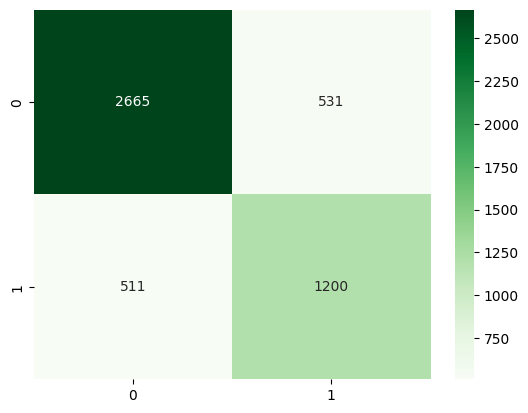

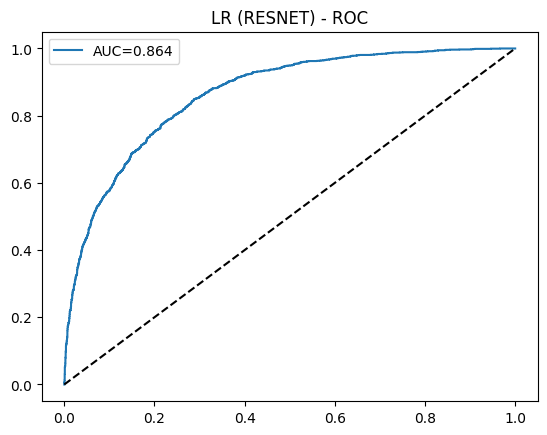

In [8]:
scaler = StandardScaler()
resnet_X_train_s = scaler.fit_transform(resnet_X_train)
resnet_X_test_s = scaler.transform(resnet_X_test)

lr_resnet = LogisticRegression(max_iter=5000)
lr_resnet.fit(resnet_X_train_s, resnet_y_train)

y_pred_train = lr_resnet.predict(resnet_X_train_s)

train_accuracy = accuracy_score(resnet_y_train, y_pred_train)
train_precision = precision_score(resnet_y_train, y_pred_train)
train_recall = recall_score(resnet_y_train, y_pred_train)
train_f1 = f1_score(resnet_y_train, y_pred_train)

print("🔹 TRAINING METRICS")
print("Accuracy:", train_accuracy)
print("Precision:", train_precision)
print("Recall:", train_recall)
print("F1-Score:", train_f1)
print("-" * 60)

y_pred_test = lr_resnet.predict(resnet_X_test_s)

test_accuracy = accuracy_score(resnet_y_test, y_pred_test)
test_precision = precision_score(resnet_y_test, y_pred_test)
test_recall = recall_score(resnet_y_test, y_pred_test)
test_f1 = f1_score(resnet_y_test, y_pred_test)

print("🔹 TESTING METRICS")
print("Accuracy:", test_accuracy)
print("Precision:", test_precision)
print("Recall:", test_recall)
print("F1-Score:", test_f1)
print("-" * 60)

print("\n🔹 Classification Report:")
print(classification_report(resnet_y_test, y_pred_test))

cm = confusion_matrix(resnet_y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.show()

y_prob = lr_resnet.predict_proba(resnet_X_test_s)[:, 1]
fpr, tpr, _ = roc_curve(resnet_y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("LR (RESNET) - ROC")
plt.legend()
plt.show()